In [11]:
%load_ext autoreload
%autoreload 2
from modules.sophrosyne import SimulationRunner, LinzSprott, Plotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0, a=0.53)
N=1, ε=0, dt=0.005, steps=1000000, threshold=100
Window=100000, save_full=False
--------------------------------------------------

  *** ESCAPE at step 8169 (t=40.8450)
      Kind: element, Means: [100.0037112   59.15247269  35.34400661]

Completed 8170 steps in 0.67s
Escaped: True


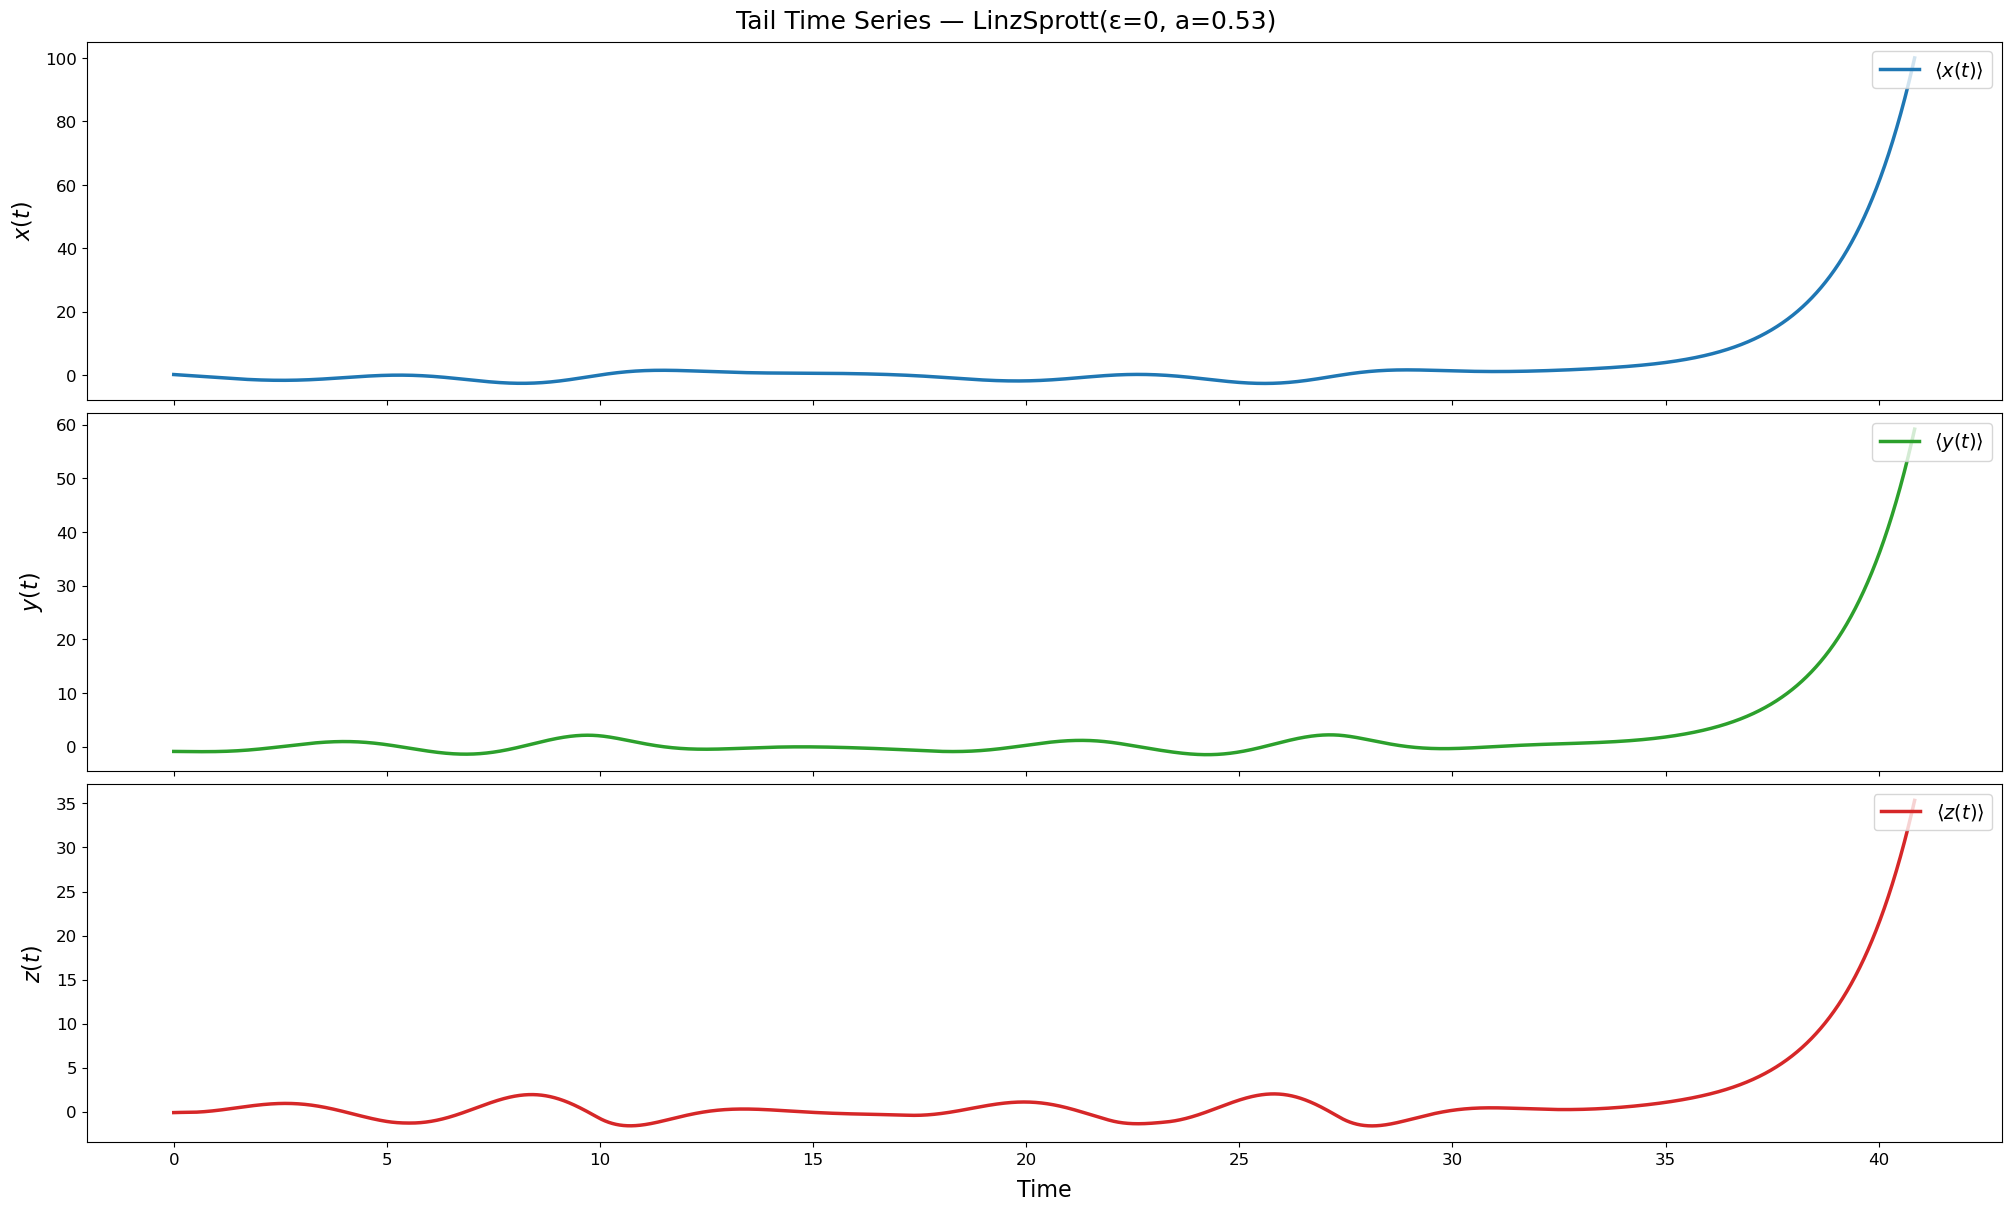

In [21]:
runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.53},
    N=1,
    epsilon=0,
    dt=0.005,
    steps=1000000,
    window=100000,
    threshold=100
)
result = runner.run()
Plotter.plot_tail_timeseries(result=result, show=True )


    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0.1, a=0.53)
N=200, ε=0.1, dt=0.05, steps=1000000, threshold=100
Window=1000, save_full=False
--------------------------------------------------
  [ 10.0%] step   100000/1000000  (9.8s elapsed)
  [ 20.0%] step   200000/1000000  (19.6s elapsed)
  [ 30.0%] step   300000/1000000  (29.4s elapsed)
  [ 40.0%] step   400000/1000000  (39.2s elapsed)
  [ 50.0%] step   500000/1000000  (49.2s elapsed)
  [ 60.0%] step   600000/1000000  (59.0s elapsed)
  [ 70.0%] step   700000/1000000  (68.7s elapsed)
  [ 80.0%] step   800000/1000000  (78.5s elapsed)
  [ 90.0%] step   900000/1000000  (88.2s elapsed)
  [100.0%] step  1000000/1000000  (98.0s elapsed)

Completed 1000000 steps in 97.97s
Escaped: False


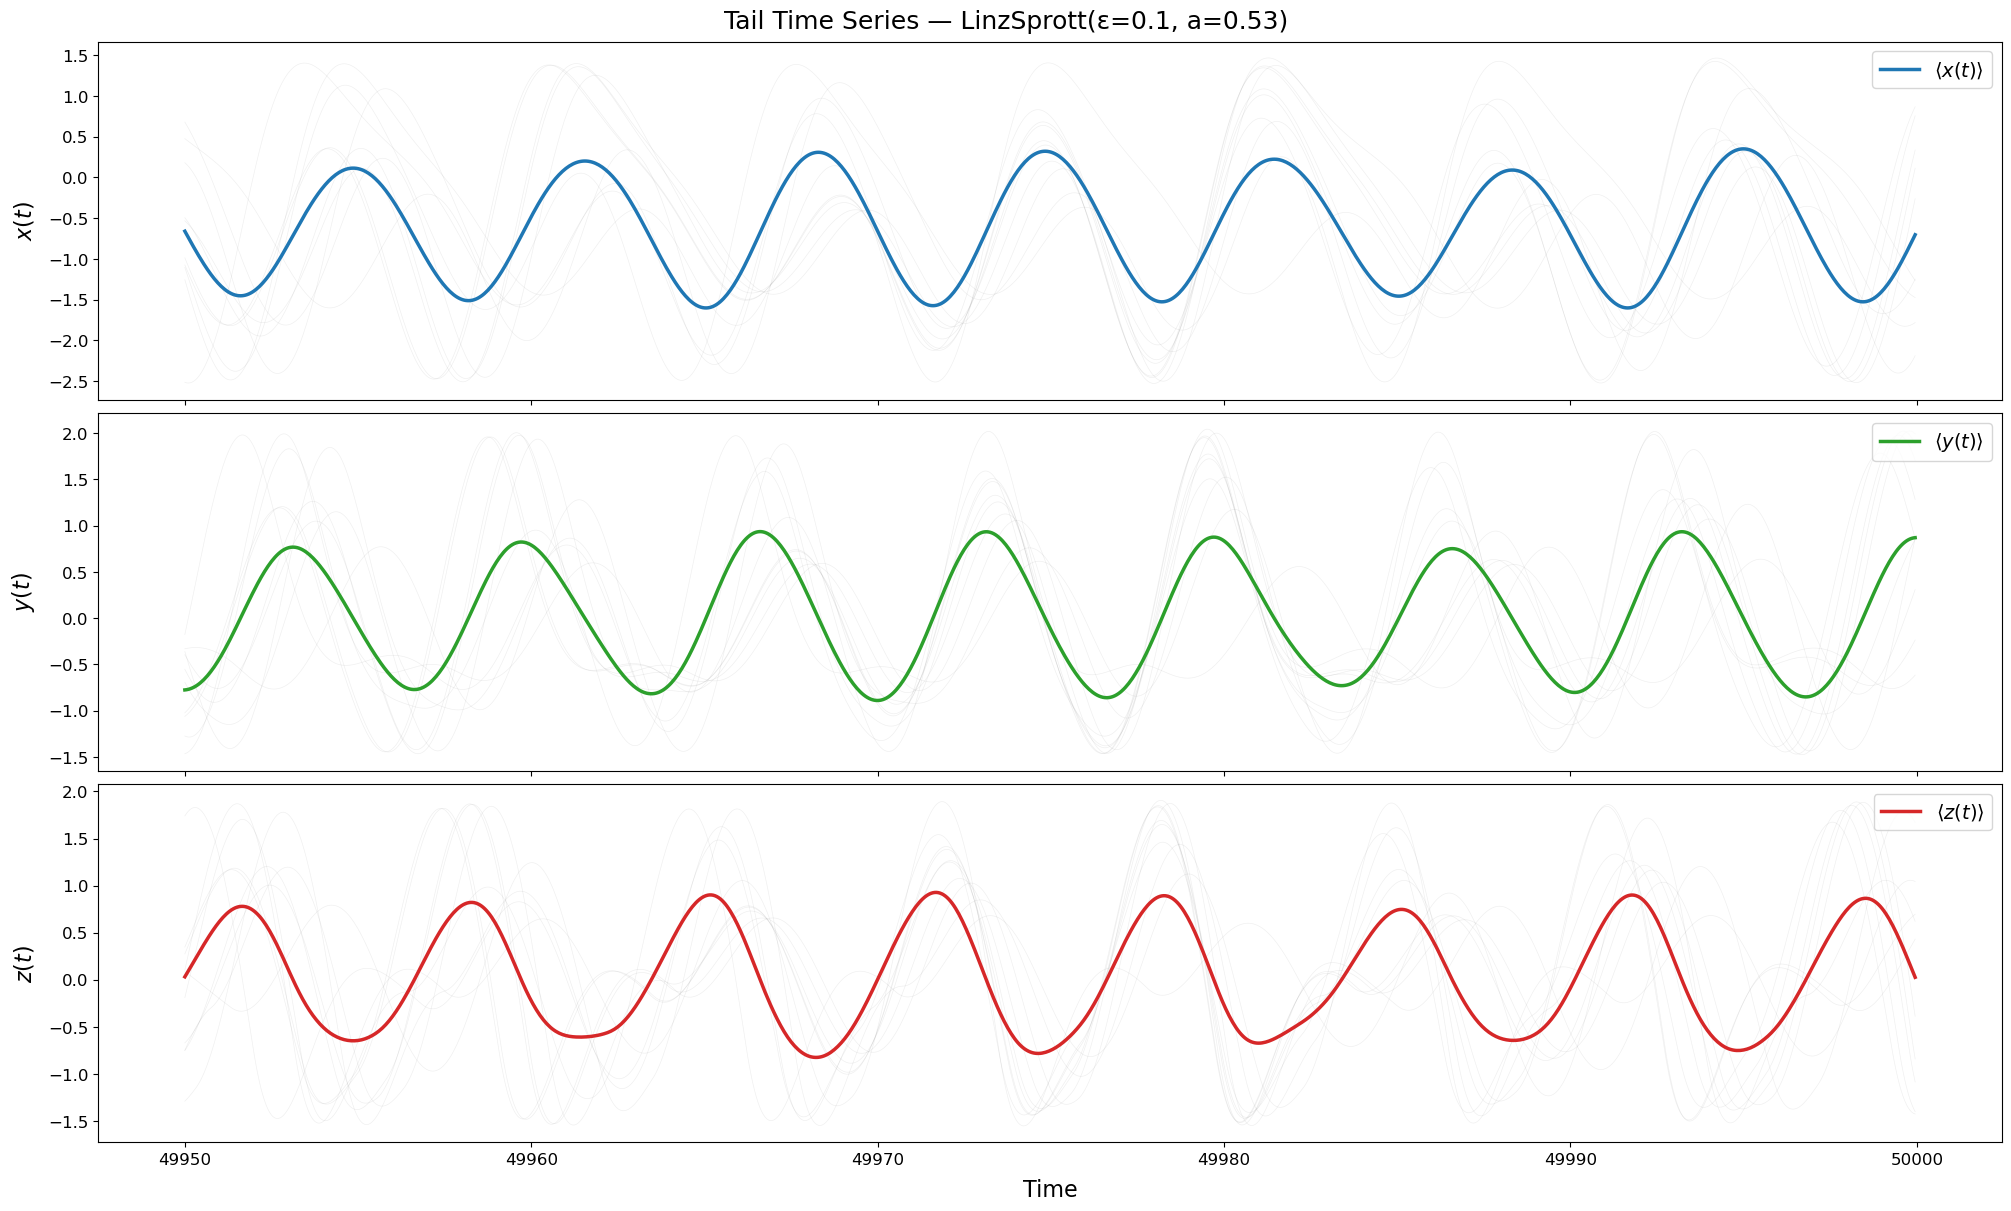

In [ ]:
runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.53},
    N=200,
    epsilon=0.1,
    dt=0.1,
    steps=1000000,
    window=1000,
    threshold=100,
    ic_spread=0.6,

)
result = runner.run()
Plotter.plot_tail_timeseries(result=result, show=True )


    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0.2, a=0.52)
N=10000, ε=0.2, dt=0.1, steps=1000000, threshold=200
Window=1000, save_full=False
--------------------------------------------------
  [ 10.0%] step   100000/1000000  (56.6s elapsed)
  [ 20.0%] step   200000/1000000  (115.9s elapsed)
  [ 30.0%] step   300000/1000000  (176.4s elapsed)
  [ 40.0%] step   400000/1000000  (235.3s elapsed)
  [ 50.0%] step   500000/1000000  (293.6s elapsed)
  [ 60.0%] step   600000/1000000  (353.2s elapsed)
  [ 70.0%] step   700000/1000000  (409.9s elapsed)
  [ 80.0%] step   800000/1000000  (468.7s elapsed)
  [ 90.0%] step   900000/1000000  (536.6s elapsed)
  [100.0%] step  1000000/1000000  (601.5s elapsed)

Completed 1000000 steps in 601.55s
Escaped: 

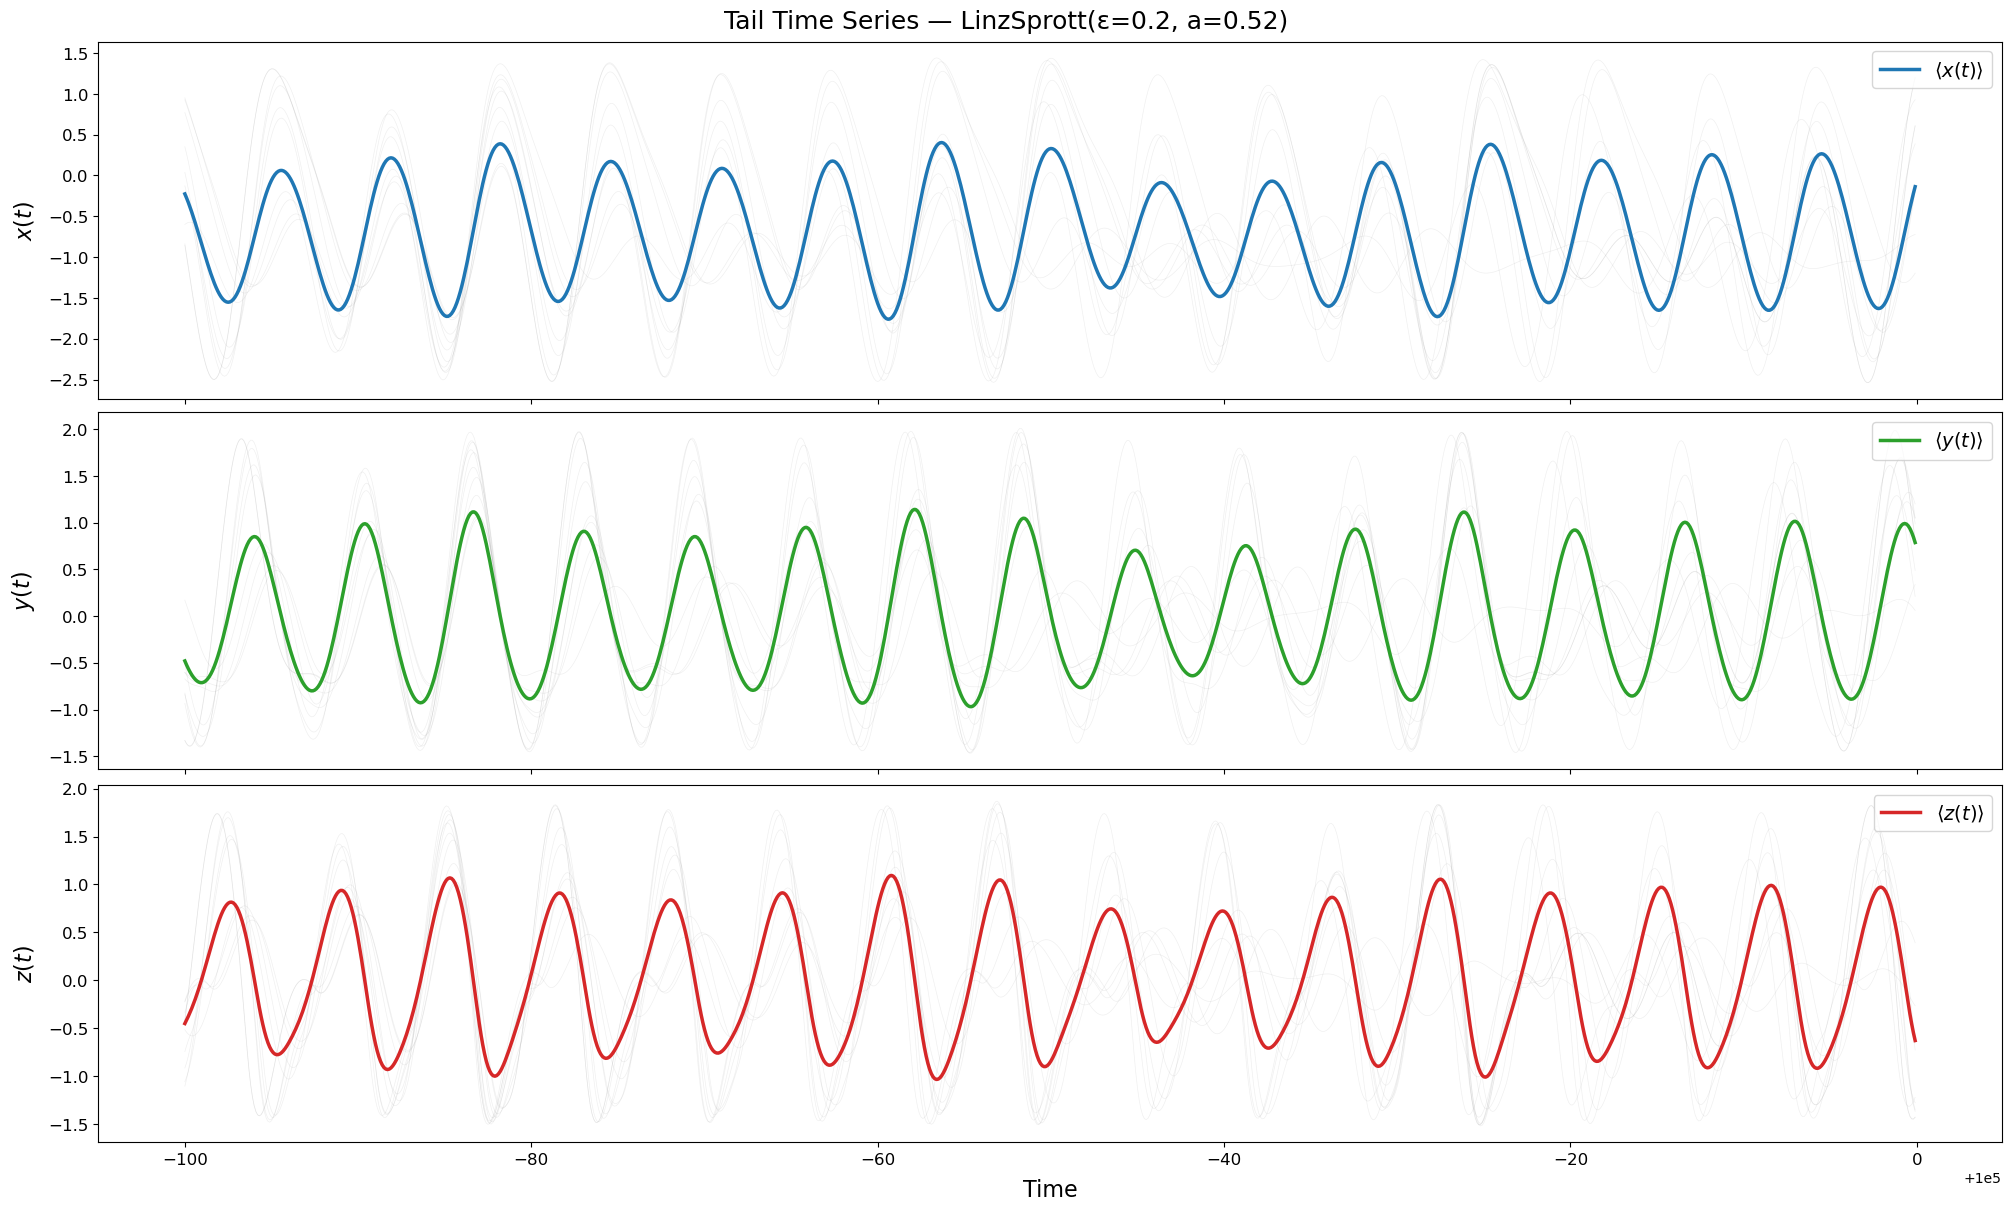

In [34]:
runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.52},
    N=10000,
    epsilon=0.2,
    dt=0.1,
    steps=1000000,
    window=1000,
    threshold=200,
    ic_spread=0.6,

)
result = runner.run()
Plotter.plot_tail_timeseries(result=result, show=True )

In [1]:
%load_ext autoreload
%autoreload 2
from modules.sophrosyne import BifurcationAnalyzer, BifurcationPlotter, LinzSprott
import numpy as np

Bifurcation sweep: 500 values of 'a' on 4 workers — N=1 [DOP853] …


Done in 93.1 s


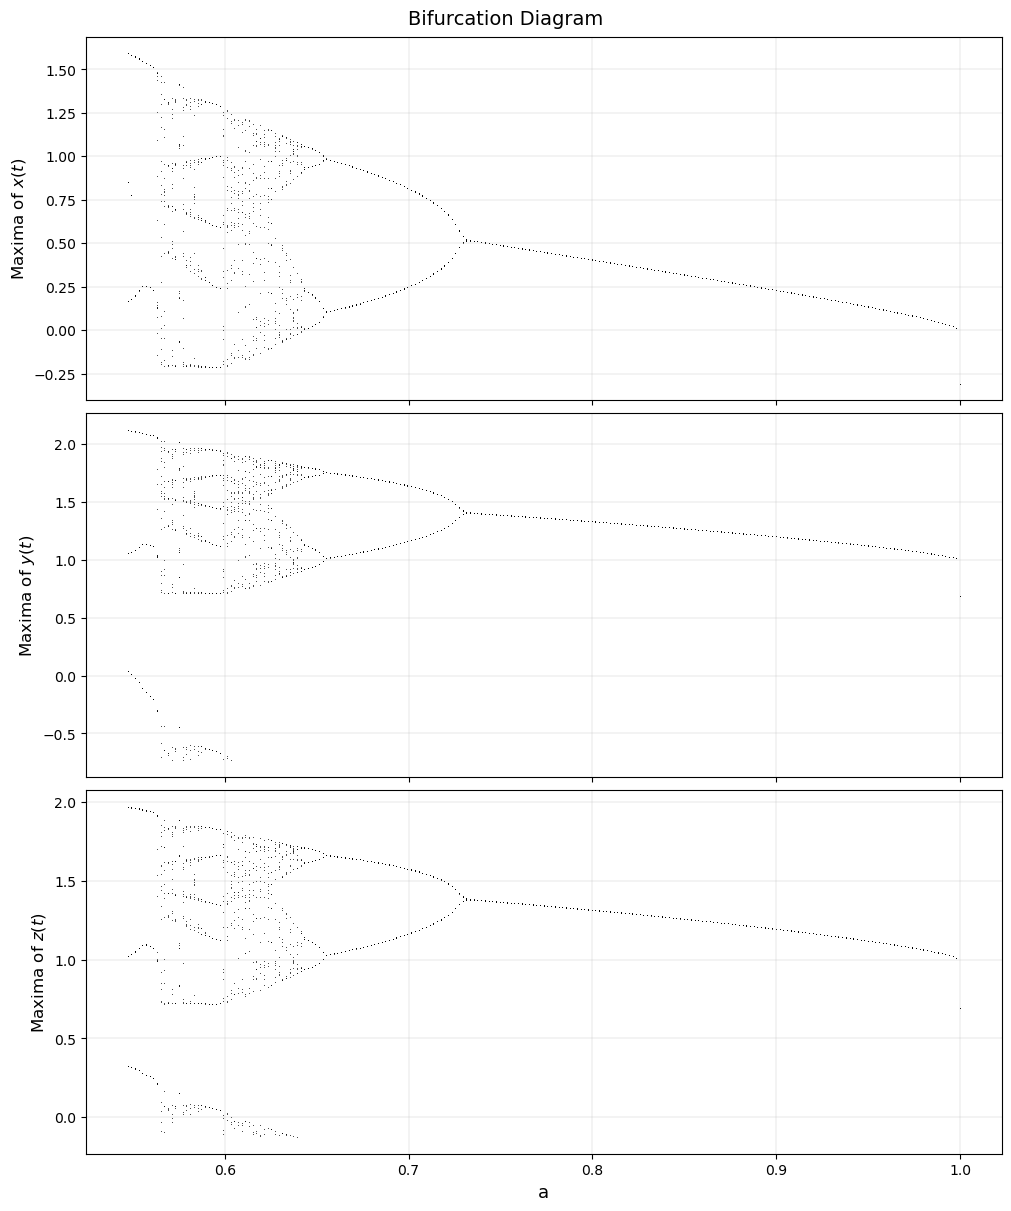

In [2]:
analyzer = BifurcationAnalyzer(
    system_cls=LinzSprott,
    base_params={},
    N=1, epsilon=0.0,
    t_transient=500.0,
    t_steady=500.0,
    dt=0.1,
    peak_keep=20,
    min_peak_period=0.5,
    threshold=100.0,
    n_jobs=4,
)

result = analyzer.compute("a", np.linspace(0, 1, 500))
BifurcationPlotter.plot(result, show=True)


Bifurcation sweep: 100 values of 'a' on 4 workers — N=200, ε=0.1, variable='mean' [RK4] …
Done in 15.1 s


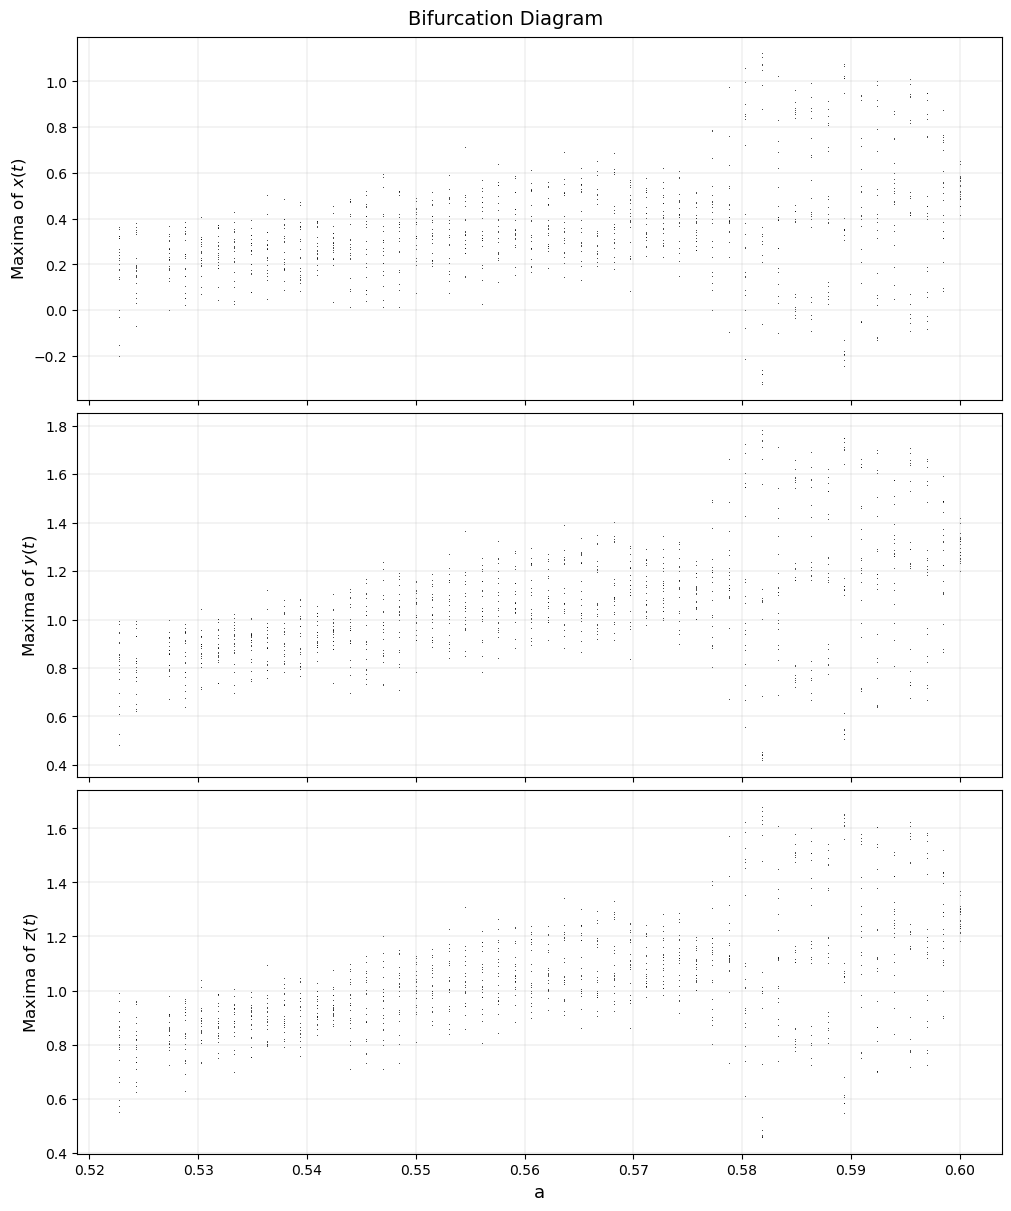

In [24]:
analyzer = BifurcationAnalyzer(
    system_cls=LinzSprott,
    base_params={},
    N=200,
    epsilon=0.1,
    t_transient=500.0,
    t_steady=500.0,
    dt=0.1,
    peak_keep=20,
    min_peak_period=0.5,
    variable="mean",       # tracks ensemble mean field
    n_jobs=4,
)

result = analyzer.compute("a", np.linspace(0.45, 0.6, 100))
BifurcationPlotter.plot(result, show=True)


Bifurcation sweep: 100 values of 'a' on 4 workers — N=1000, ε=0.1, variable='mean' [RK4] …


Done in 24.0 s


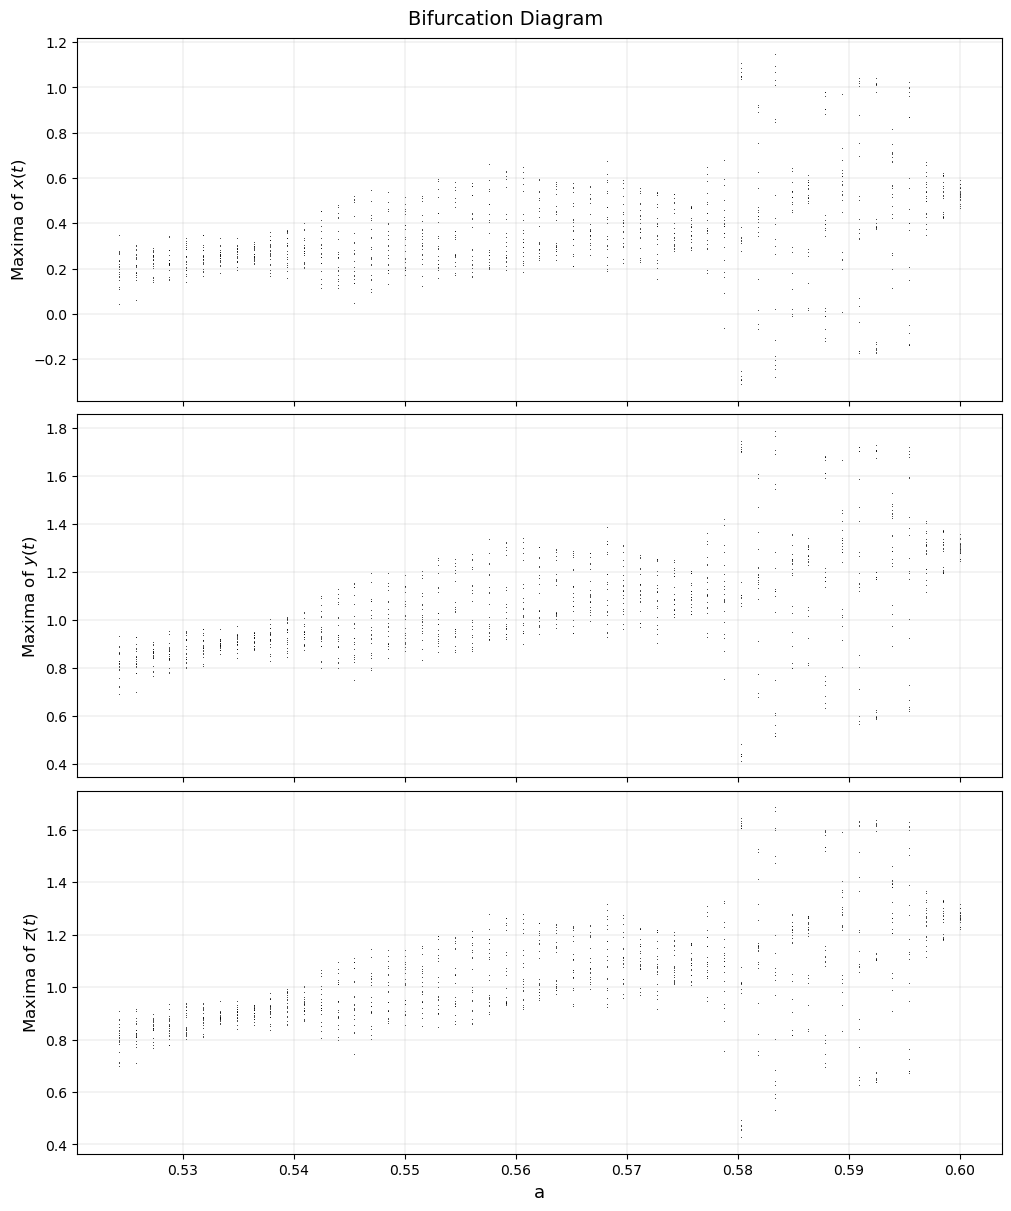

In [25]:
analyzer = BifurcationAnalyzer(
    system_cls=LinzSprott,
    base_params={},
    N=1000,
    epsilon=0.1,
    t_transient=500.0,
    t_steady=500.0,
    dt=0.1,
    peak_keep=20,
    min_peak_period=0.5,
    variable="mean",       # tracks ensemble mean field
    n_jobs=4,
)

result = analyzer.compute("a", np.linspace(0.45, 0.6, 100))
BifurcationPlotter.plot(result, show=True)



    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0.1, a=0.53)
N=200, ε=0.1, dt=0.1, steps=10000, threshold=200
Window=1000, save_full=False
--------------------------------------------------
  [ 10.0%] step     1000/10000  (0.1s elapsed)
  [ 20.0%] step     2000/10000  (0.2s elapsed)
  [ 30.0%] step     3000/10000  (0.3s elapsed)
  [ 40.0%] step     4000/10000  (0.4s elapsed)
  [ 50.0%] step     5000/10000  (0.5s elapsed)
  [ 60.0%] step     6000/10000  (0.6s elapsed)
  [ 70.0%] step     7000/10000  (0.7s elapsed)
  [ 80.0%] step     8000/10000  (0.8s elapsed)
  [ 90.0%] step     9000/10000  (0.9s elapsed)
  [100.0%] step    10000/10000  (1.0s elapsed)

Completed 10000 steps in 0.99s
Escaped: False


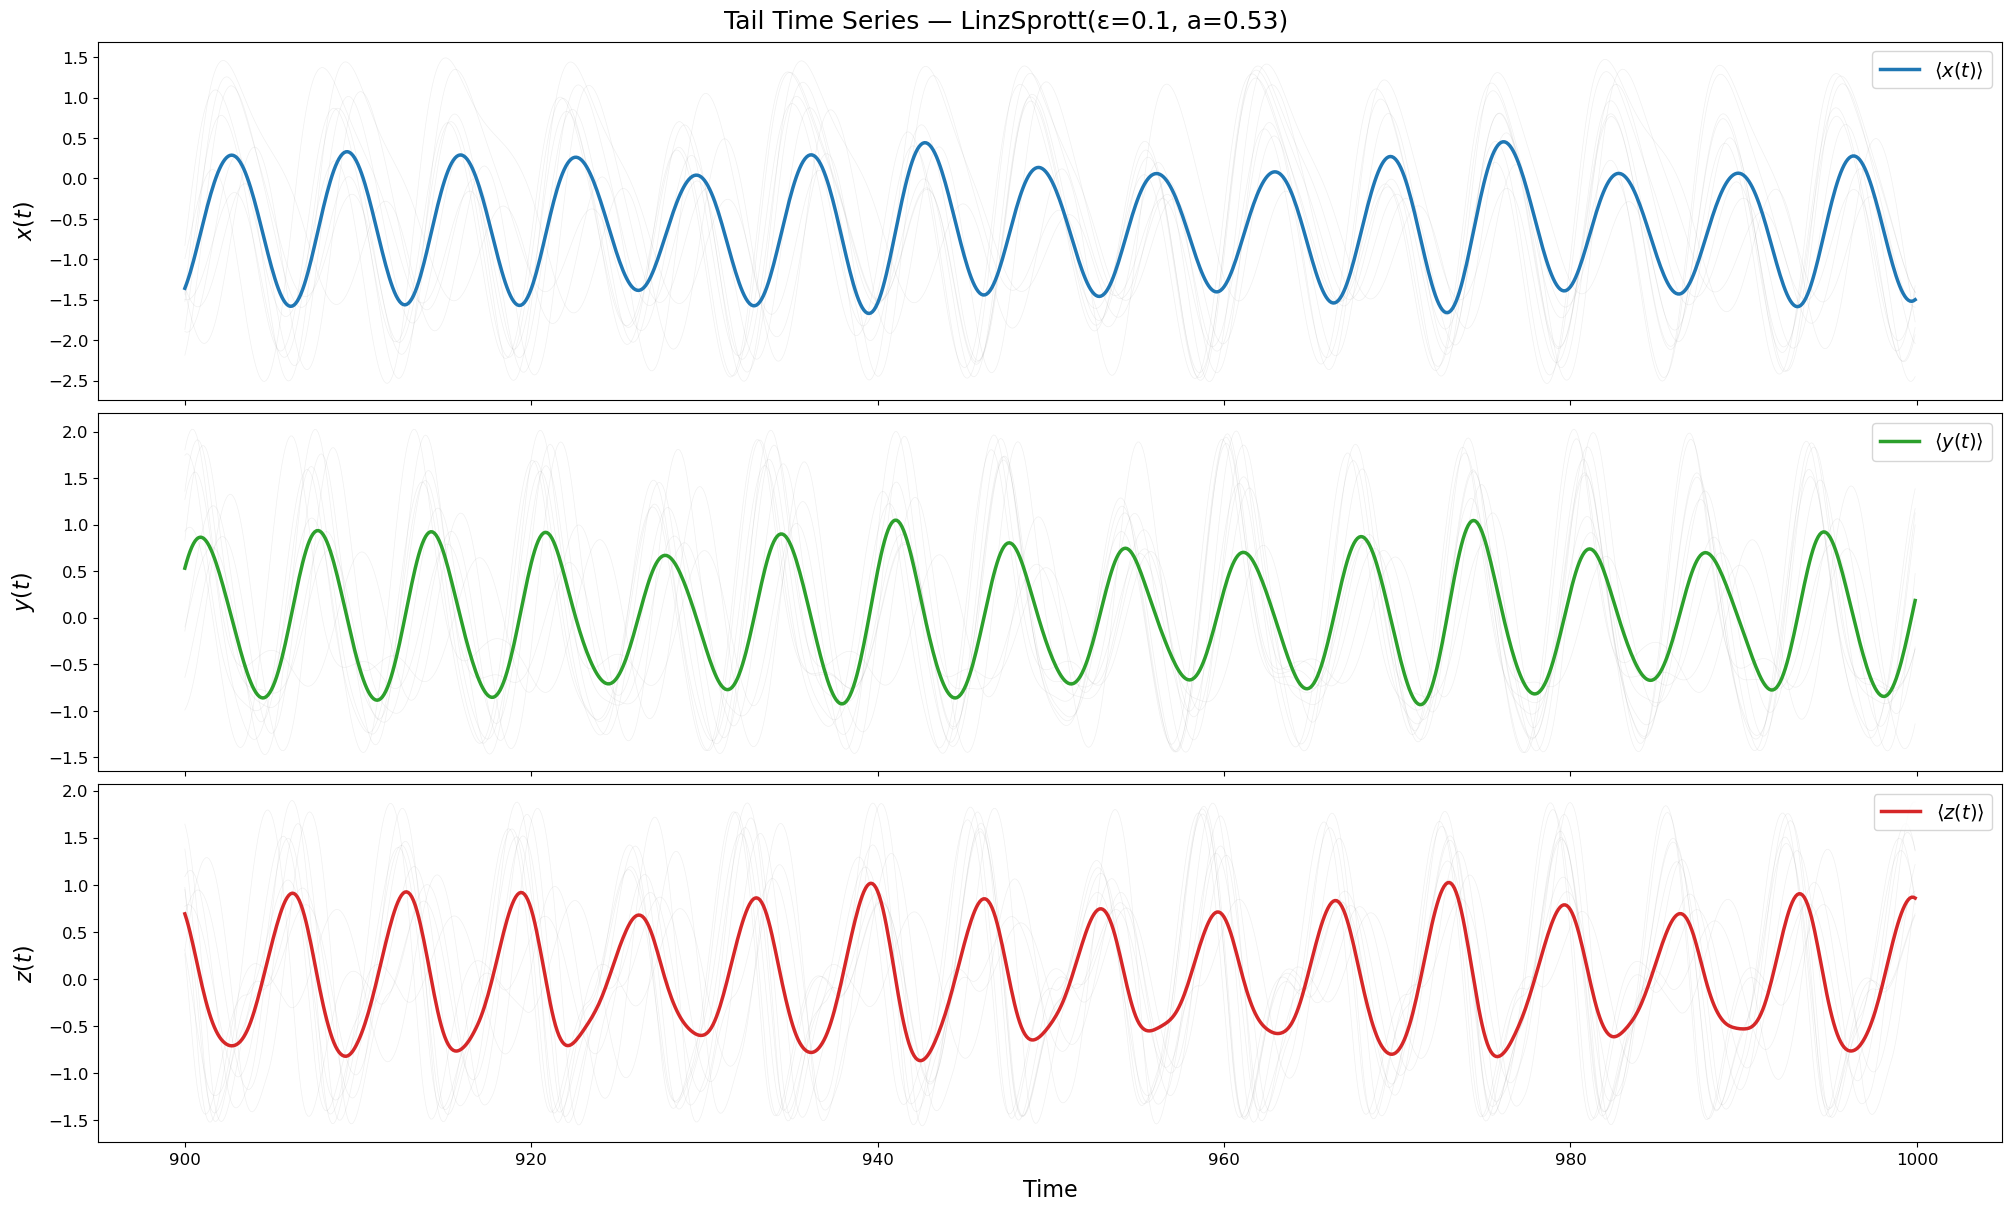

In [26]:
runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.53},
    N=200,
    epsilon=0.1,
    dt=0.1,
    steps=10000,
    window=1000,
    threshold=200,
    ic_spread=0.6,

)
result = runner.run()
Plotter.plot_tail_timeseries(result=result, show=True )

# Map

In [1]:
from modules.sophrosyne import EscapeMapAnalyzer, EscapeMapPlotter, LinzSprott
import numpy as np

Escape map (fixed N=50): 20×20 = 400 points on 8 workers …
Done in 68.8 s


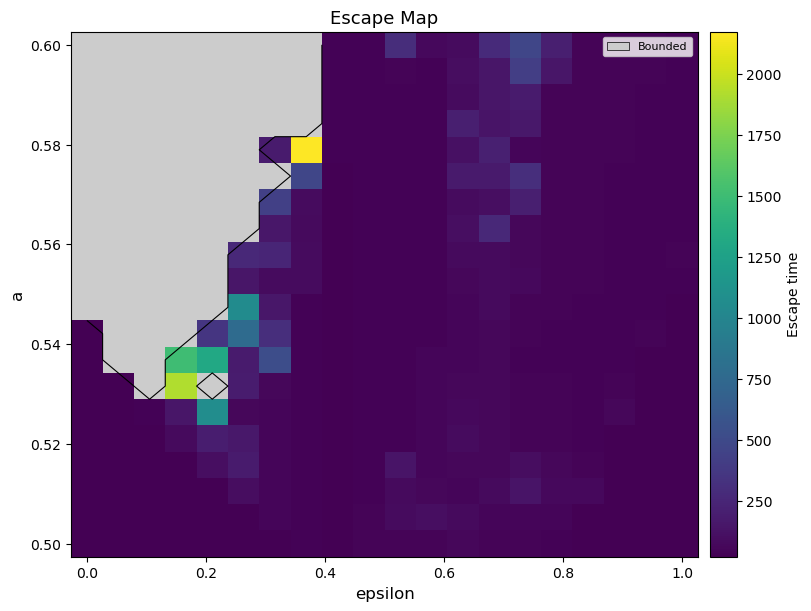

In [4]:
analyzer = EscapeMapAnalyzer(
    system_cls=LinzSprott, base_params={},
    epsilon=0.0, dt=0.05, steps=50_000,
    threshold=100.0, n_jobs=8,
)

# Mode 1: fixed N, colour = escape time
result = analyzer.compute(
    param1_name="a",       param1_values=np.linspace(0.5, 0.6, 20),
    param2_name="epsilon", param2_values=np.linspace(0.0, 1, 20),
)
EscapeMapPlotter.plot(result, show=True, cmap="viridis")

Escape map (min-N): 10×10 = 100 points, N_max=1000, n_trials=3, workers=8 …
Done in 340.6 s


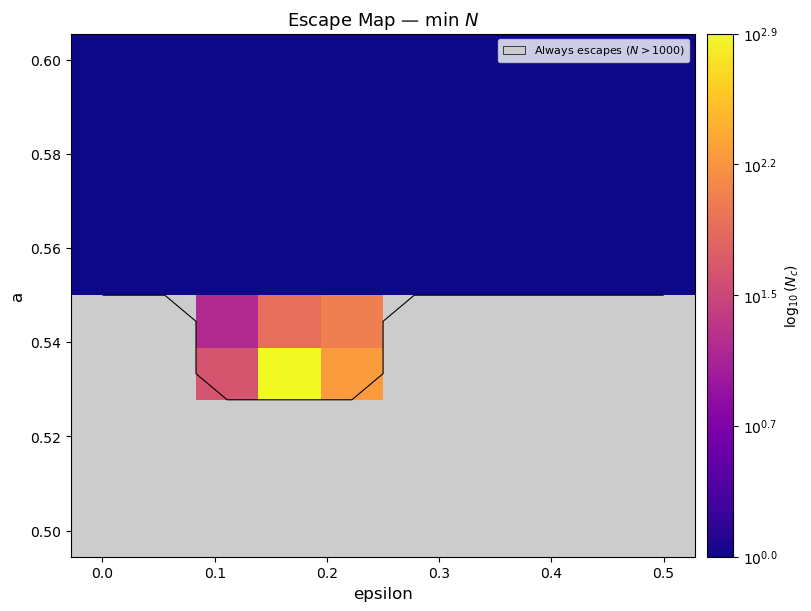

In [7]:
# Mode 2: colour = min N (analogous to discrete case)
result = analyzer.compute_min_N(
    param1_name="a",       param1_values=np.linspace(0.5, 0.6, 10),
    param2_name="epsilon", param2_values=np.linspace(0.0, 0.5, 10),
    N_min=1, N_max=1000, n_trials=3,
)
EscapeMapPlotter.plot_min_N(result, show=True, cmap="plasma")



    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0.1, a=0.53)
N=100, ε=0.1, dt=0.05, steps=200000, threshold=100.0
Window=10000, save_full=False
--------------------------------------------------
  [ 10.0%] step    20000/200000  (1.9s elapsed)
  [ 20.0%] step    40000/200000  (3.6s elapsed)
  [ 30.0%] step    60000/200000  (5.3s elapsed)
  [ 40.0%] step    80000/200000  (7.0s elapsed)
  [ 50.0%] step   100000/200000  (8.8s elapsed)
  [ 60.0%] step   120000/200000  (10.5s elapsed)
  [ 70.0%] step   140000/200000  (12.3s elapsed)
  [ 80.0%] step   160000/200000  (14.1s elapsed)
  [ 90.0%] step   180000/200000  (15.9s elapsed)
  [100.0%] step   200000/200000  (17.7s elapsed)

Completed 200000 steps in 17.70s
Escaped: False


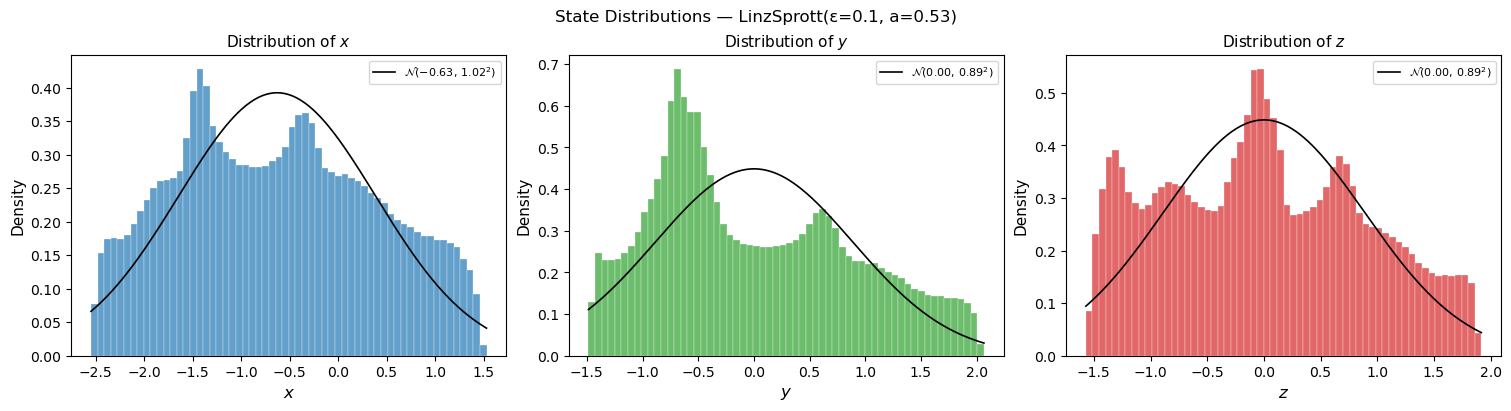

In [ ]:
from modules.sophrosyne import SimulationRunner, HistogramPlotter, LinzSprott

runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.53},
    N=100,
    epsilon=0.1,
    dt=0.05,
    steps=200000,
    window=10000,
)
result = runner.run()

HistogramPlotter.plot(result, show=True)

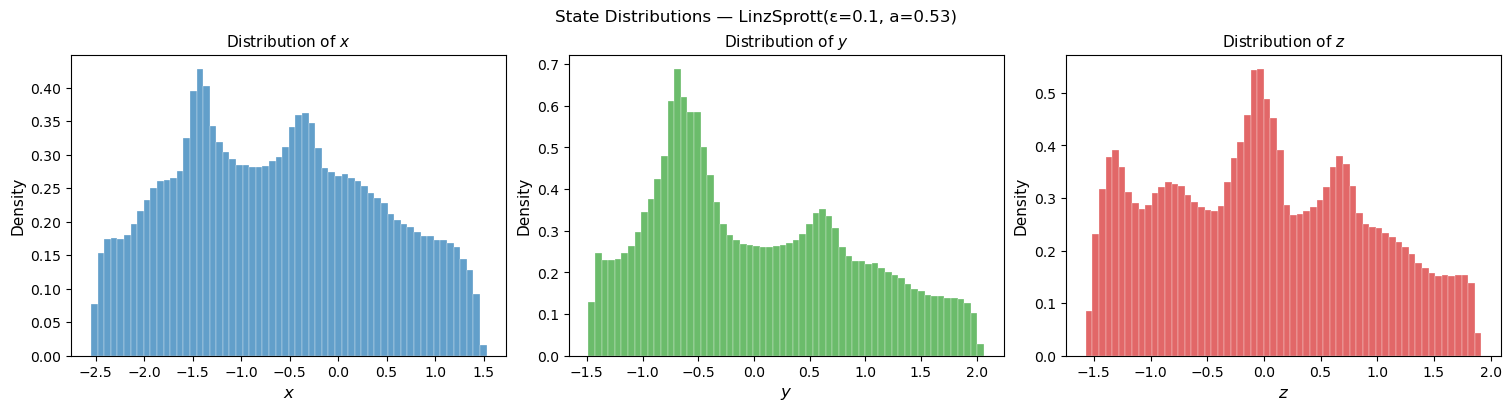

In [12]:
HistogramPlotter.plot(result, show=True, gaussian_fit=False)


    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0, a=0.6)
N=1, ε=0, dt=0.05, steps=200000, threshold=100.0
Window=10000, save_full=False
--------------------------------------------------
  [ 10.0%] step    20000/200000  (1.7s elapsed)
  [ 20.0%] step    40000/200000  (3.4s elapsed)
  [ 30.0%] step    60000/200000  (5.1s elapsed)
  [ 40.0%] step    80000/200000  (6.8s elapsed)
  [ 50.0%] step   100000/200000  (8.6s elapsed)
  [ 60.0%] step   120000/200000  (10.2s elapsed)
  [ 70.0%] step   140000/200000  (12.0s elapsed)
  [ 80.0%] step   160000/200000  (13.7s elapsed)
  [ 90.0%] step   180000/200000  (15.3s elapsed)
  [100.0%] step   200000/200000  (17.1s elapsed)

Completed 200000 steps in 17.08s
Escaped: False


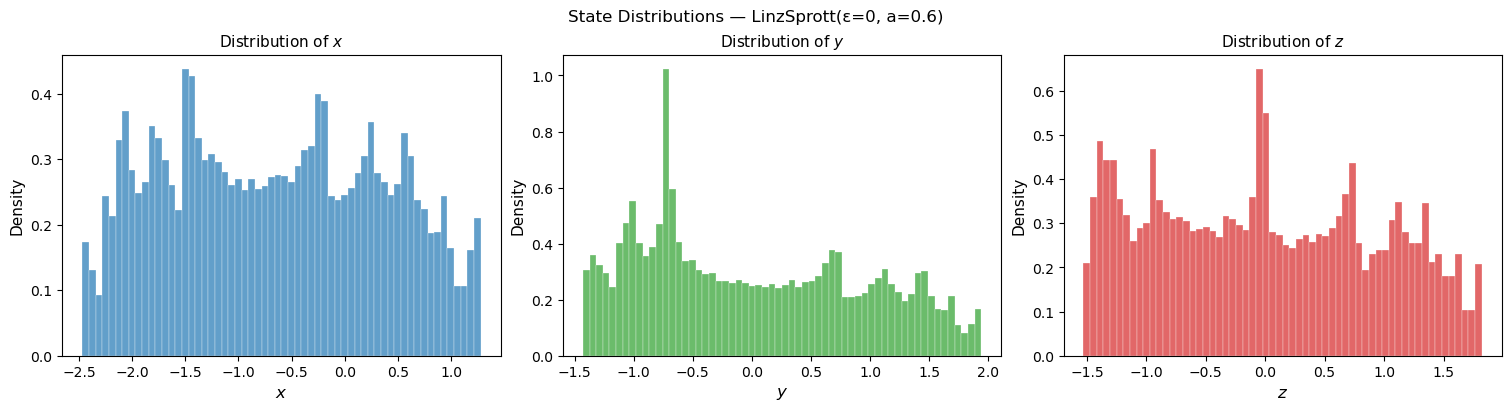

In [13]:
from modules.sophrosyne import SimulationRunner, HistogramPlotter, LinzSprott

runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.6},
    N=1,
    epsilon=0,
    dt=0.05,
    steps=200000,
    window=10000,
)
result = runner.run()

HistogramPlotter.plot(result, show=True, gaussian_fit=False)


    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0, a=0.7)
N=1, ε=0, dt=0.05, steps=200000, threshold=100.0
Window=10000, save_full=False
--------------------------------------------------
  [ 10.0%] step    20000/200000  (1.8s elapsed)
  [ 20.0%] step    40000/200000  (3.5s elapsed)
  [ 30.0%] step    60000/200000  (5.3s elapsed)
  [ 40.0%] step    80000/200000  (7.0s elapsed)
  [ 50.0%] step   100000/200000  (8.7s elapsed)
  [ 60.0%] step   120000/200000  (10.5s elapsed)
  [ 70.0%] step   140000/200000  (12.3s elapsed)
  [ 80.0%] step   160000/200000  (14.1s elapsed)
  [ 90.0%] step   180000/200000  (16.0s elapsed)
  [100.0%] step   200000/200000  (17.7s elapsed)

Completed 200000 steps in 17.70s
Escaped: False


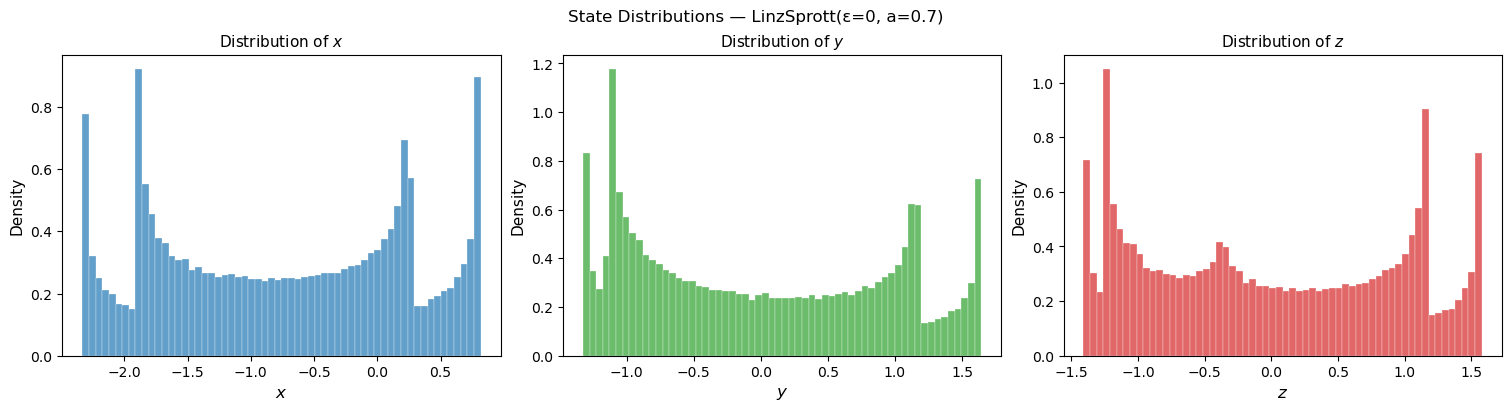

In [14]:
from modules.sophrosyne import SimulationRunner, HistogramPlotter, LinzSprott

runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.7},
    N=1,
    epsilon=0,
    dt=0.05,
    steps=200000,
    window=10000,
)
result = runner.run()

HistogramPlotter.plot(result, show=True, gaussian_fit=False)


    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0, a=0.8)
N=1, ε=0, dt=0.05, steps=200000, threshold=100.0
Window=10000, save_full=False
--------------------------------------------------
  [ 10.0%] step    20000/200000  (1.7s elapsed)
  [ 20.0%] step    40000/200000  (3.3s elapsed)
  [ 30.0%] step    60000/200000  (5.0s elapsed)
  [ 40.0%] step    80000/200000  (6.7s elapsed)
  [ 50.0%] step   100000/200000  (8.3s elapsed)
  [ 60.0%] step   120000/200000  (10.0s elapsed)
  [ 70.0%] step   140000/200000  (11.7s elapsed)
  [ 80.0%] step   160000/200000  (13.5s elapsed)
  [ 90.0%] step   180000/200000  (15.2s elapsed)
  [100.0%] step   200000/200000  (16.9s elapsed)

Completed 200000 steps in 16.93s
Escaped: False


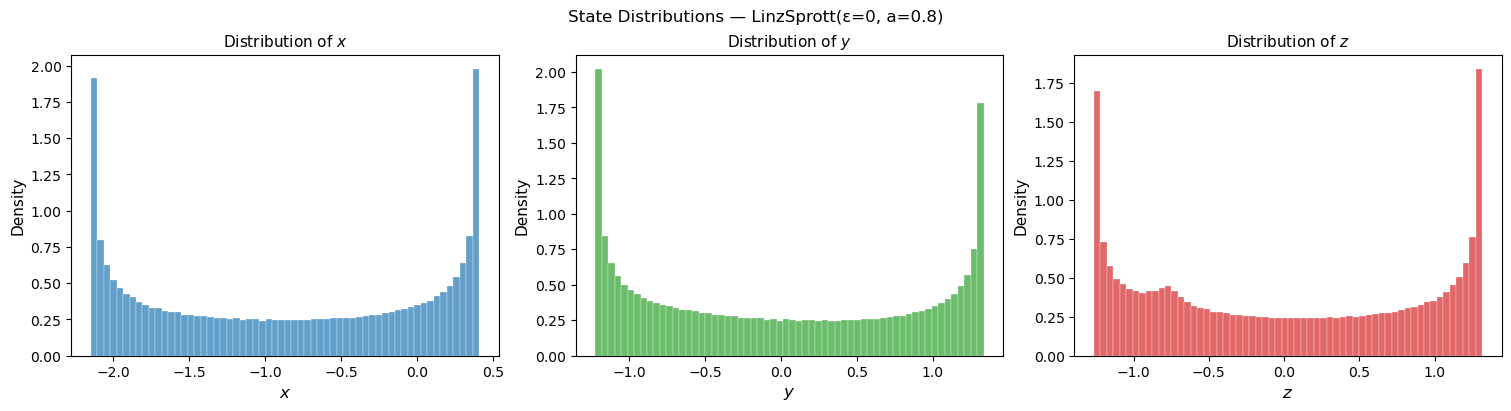

In [15]:
from modules.sophrosyne import SimulationRunner, HistogramPlotter, LinzSprott

runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.8},
    N=1,
    epsilon=0,
    dt=0.05,
    steps=200000,
    window=10000,
)
result = runner.run()

HistogramPlotter.plot(result, show=True, gaussian_fit=False)

In [ ]:
from modules.sophrosyne import SimulationRunner, HistogramPlotter, LinzSprott

runner = SimulationRunner(
    system_cls=LinzSprott,
    system_params={"a": 0.53},
    N=1000,
    epsilon=0.1,
    dt=0.05,
    steps=200000,
    window=10000,
)
result = runner.run()

HistogramPlotter.plot(result, show=True, gaussian_fit=False)


    ╔══════════════════════════════════════╗
    ║             SOPHROSYNE               ║
    ║              v1.0.0                  ║
    ║   Coupled Dynamical Systems Solver   ║
    ║            by R.S.S.G.               ║
    ╚══════════════════════════════════════╝
    
System   : LinzSprott(ε=0.1, a=0.53)
N=1000, ε=0.1, dt=0.05, steps=200000, threshold=100.0
Window=10000, save_full=False
--------------------------------------------------
  [ 10.0%] step    20000/200000  (3.0s elapsed)
  [ 20.0%] step    40000/200000  (5.8s elapsed)
  [ 30.0%] step    60000/200000  (8.7s elapsed)
  [ 40.0%] step    80000/200000  (11.5s elapsed)
  [ 50.0%] step   100000/200000  (14.4s elapsed)
